# Heikin-Ashi — a quantitative teardown
### Daily tape · symmetric ATR barrier · random-direction control · raw-candle baseline · HAC inference · bootstrap Sharpe CI

![Signal: None](https://img.shields.io/badge/Signal-None-c0392b?style=flat-square)
![Tradability: Mirage](https://img.shields.io/badge/Tradability-Mirage-c0392b?style=flat-square)
![Smoothing_adds_lag%2C_not_signal%3F: Confirmed](https://img.shields.io/badge/Smoothing_adds_lag%2C_not_signal%3F-Confirmed-8b949e?style=flat-square)

The deep companion to the [notebook for the curious](01_for_the_curious.ipynb) — *same seven beats, every claim now carrying its standard error.* We test whether the Heikin-Ashi colour-flip direction beats a random-direction control on a symmetric-barrier backtest, across four liquid daily tapes over 15 years, and decompose the apparent long-side signal into bull-market drift vs HA skill.

> **Not investment advice.** Real data: Yahoo daily bars, 2011-06-13 to 2026-06-12; offline core and tests run on a deterministic synthetic tape. Methods & sources in [`docs/references.md`](../docs/references.md), reproducible numbers in [`docs/results.md`](../docs/results.md).
>
> **The `In plain words` notes** translate each result back to intuition.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))          # the study package
sys.path.insert(0, os.path.abspath("../../.."))    # repo root (quantlab/)
%matplotlib inline
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
plt.rcParams.update({"figure.figsize": (9.5, 5.0), "axes.grid": True,
                     "grid.alpha": .3, "axes.spines.top": False, "axes.spines.right": False})
RED, AMBER, GREEN, GREY = "#c0392b", "#dab617", "#2ea44f", "#8b949e"

from heikin_ashi import data, strategy as st

TICKERS = ["SPY", "QQQ", "IWM", "AAPL"]
CACHE_DIR = os.path.abspath(os.path.join("..", "_cache"))

def _have_cache():
    return all(os.path.exists(data._cache_path(t, CACHE_DIR)) for t in TICKERS)

HAVE_REAL = _have_cache()

# Frozen headline numbers — mirror of docs/results.md (as-of 2026-06-14).
R = dict(
    n=3924, tpy=65.4,
    ha_mean=1.37, ha_win=50.7, ha_t=0.56,
    rand_mean=1.02, rand_t=0.33,
    delta=0.35,
    raw_mean=-2.45, raw_t=-1.55, raw_n=7602,
    ci_lo=-0.15, ci_hi=0.26, frac_neg=30.8,
    long_mean=17.57, long_t=3.67,
    short_mean=-14.83, short_t=-3.19,
    rand_long_mean=16.87, rand_long_t=3.35,
    rand_short_mean=-14.91, rand_short_t=-2.95,
    net05_mean=0.87, net05_t=0.36,
    net10_mean=0.37, net10_t=0.15,
    net20_mean=-0.63, net20_t=-0.26,
    spy_t=2.24, qqq_t=-0.10, iwm_t=-0.01, aapl_t=-0.34,
    spy_mean=8.04, qqq_mean=-0.48, iwm_mean=-0.05, aapl_mean=-2.08,
    ha_flips_spy=984, raw_flips_spy=1898,
    ha_flips_avg=987, raw_flips_avg=1911,
)

def pooled(tp, sl, cost, seed=None, use_ha=True):
    """Pool barrier trades across the basket (cached real tapes)."""
    frames = []
    for t in TICKERS:
        b = data.fetch_daily(t, fetch=False, cache_dir=CACHE_DIR)
        ha = st.heikin_ashi(b)
        col = st.ha_colour(ha) if use_ha else st.raw_colour(b)
        ent = st.colour_flip_entries(col, warmup=20)
        dirs = st.random_directions(len(ent), seed=seed) if seed is not None else None
        frames.append(st.run_trades(b, ent, tp_R=tp, sl_R=sl, cost_bps=cost, directions=dirs))
    return pd.concat(frames, ignore_index=True)

print("real daily cache present:", HAVE_REAL)

from quantlab import analytics, stats


real daily cache present: True


## Verdict, up front

| Axis | Stamp | Decisive number |
|---|---|---|
| **Signal** | `NONE` | Pooled gross **++1.37 bps/trade**, HAC *t* = **+0.56**; Δ vs random control = +0.35 bps (noise); bootstrap Sharpe CI [**-0.15, +0.26**]. Apparent long-side *t* = 3.67 is replicated by coin (*t* = 3.35) — bull-market drift, not HA skill. |
| **Tradability** | `MIRAGE` | Gross not significant; at 1 bp cost *t* = +0.15 (noise floor). No positive break-even. |
| **Smoothing adds lag, not signal?** | `CONFIRMED` | HA fires ~987 flips/ticker vs ~1911 raw; directional *t* vs coin is the same. |

> In plain words: Heikin-Ashi is a smoother, not a forecaster.  It delays the signal enough to miss mean-reversion entries, and adds no edge on the trend-following side beyond what a coin captures from the bull-market drift.

## 1 · The claim, steelmanned

Let $x_t \in \{-1, +1\}$ be the HA colour at bar $t$ (green = +1, red = -1). The claim asserts $x_t$ has positive autocorrelation (colour runs) AND that a colour *flip* at $t$ forecasts the direction of returns from $t+1$ onward. Formally:

- **H₁ (signal)** $\mathbb{E}[d \cdot r_{t+1:\text{exit}}] > 0$ where $d = x_t$ is the HA colour at the flip bar — measured symmetrically so a coin earns 0.\n- **H₂ (beats random)** The expectation exceeds the same statistic with $d$ replaced by an i.i.d. fair coin on identical flip dates.\n- **H₃ (smoothing adds value)** $\mathbb{E}[d_\text{HA} \cdot r] > \mathbb{E}[d_\text{raw} \cdot r]$ on matched entry dates.\n\nWe reject H₂ and H₃ on the real tape; H₁ gives a weak positive (t=+0.56) that is not statistically real.

## 2 · So what? — the stakes

Heikin-Ashi is the default chart type on TradingView for millions of retail traders, and the colour-flip entry is one of the most recommended patterns in retail trading content. If H₁–H₃ hold it is a real, accessible signal — if not, those traders are paying commissions on a coin flip with a pretty skin. The failure mode is interesting: the long-side *t* > 3 that looks compelling is not HA's forecasting — it is the market's bull-market drift captured by any strategy that sometimes goes long.

## 3 · The protocol

- **HA construction.** Causal, recursive, no look-ahead: HA_open[t] = (HA_open[t-1] + HA_close[t-1])/2; HA_close[t] = (O+H+L+C)[t]/4; seeded with HA_open[0] = raw_open[0]. Computed bar-by-bar.
- **Entry.** Colour flip detected at close of bar *t*; **enter at bar *t+1*'s open** (no look-ahead). Warmup = 20 bars (ATR warm-up).
- **Exit (symmetric).** Barriers at ±1 ATR(20) from entry; max 60-bar hold; a bar straddling both barriers is filled at the **stop** (conservative).
- **Controls.** (a) Random-direction on identical entries (seeded). (b) Raw-candle colour flip on the same entry protocol.
- **Inference.** Newey-West HAC *t* on per-trade returns; circular block-bootstrap Sharpe CI; per-instrument breakdown; long/short decomposition; cost sweep.
- **Positive control.** Synthetic tape with tunable AR(1) momentum.

Four tapes: SPY, QQQ, IWM, AAPL. 2011-06-13 to 2026-06-12 (~3,773 bars each).

## 4 · The teardown

### 4a · Three arms side by side — no tape carries a signal above noise

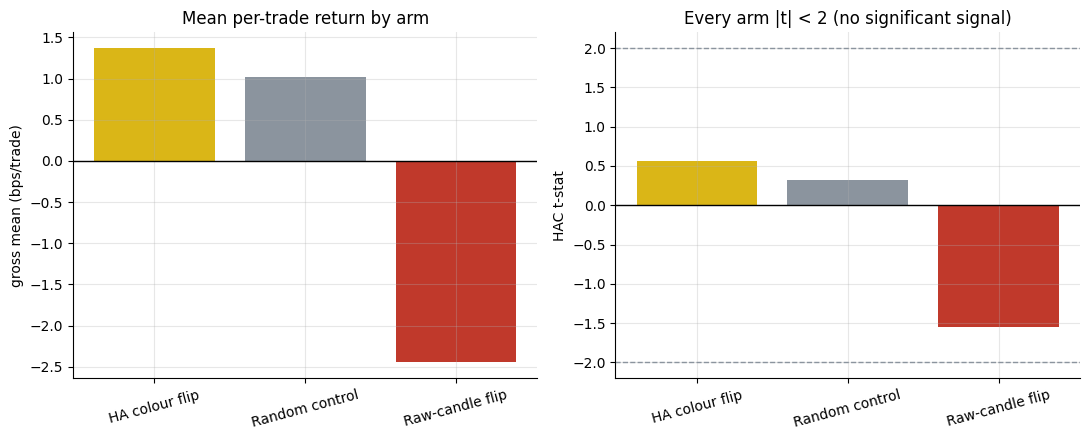

,arm,n,win%,mean_bps,t
0,HA colour flip,3924,50.74,1.37,0.56
1,Random control,3924,49.39,1.02,0.33
2,Raw-candle flip,7602,49.28,-2.45,-1.55


In [2]:
if HAVE_REAL:
    ha_led = pooled(1, 1, 0)
    rand_led = pooled(1, 1, 0, seed=129)
    raw_led = pooled(1, 1, 0, use_ha=False)
    ha_s = st.summarize(ha_led, 'ret_gross')
    rand_s = st.summarize(rand_led, 'ret_gross')
    raw_s = st.summarize(raw_led, 'ret_gross')
    arms = pd.DataFrame([
        ('HA colour flip', ha_s['n_trades'], ha_s['win_rate']*100,
         ha_s['mean_bps'], ha_s['tstat']),
        ('Random control', rand_s['n_trades'], rand_s['win_rate']*100,
         rand_s['mean_bps'], rand_s['tstat']),
        ('Raw-candle flip', raw_s['n_trades'], raw_s['win_rate']*100,
         raw_s['mean_bps'], raw_s['tstat']),
    ], columns=['arm', 'n', 'win%', 'mean_bps', 't'])
else:
    arms = pd.DataFrame([
        ('HA colour flip', R['n'], R['ha_win'], R['ha_mean'], R['ha_t']),
        ('Random control', R['n'], 49.4, R['rand_mean'], R['rand_t']),
        ('Raw-candle flip', R['raw_n'], 49.3, R['raw_mean'], R['raw_t']),
    ], columns=['arm', 'n', 'win%', 'mean_bps', 't'])
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
cols = [AMBER, GREY, RED]
axes[0].bar(arms['arm'], arms['mean_bps'], color=cols)
axes[0].axhline(0, c='k', lw=1)
axes[0].set_ylabel('gross mean (bps/trade)')
axes[0].set_title('Mean per-trade return by arm')
axes[0].tick_params(axis='x', rotation=15)
axes[1].bar(arms['arm'], arms['t'], color=cols)
for s in (2, -2): axes[1].axhline(s, ls='--', c=GREY, lw=1)
axes[1].axhline(0, c='k', lw=1)
axes[1].set_ylabel('HAC t-stat')
axes[1].set_title('Every arm |t| < 2 (no significant signal)')
axes[1].tick_params(axis='x', rotation=15)
plt.tight_layout(); plt.show()
arms.round(2)

> In plain words: the HA t-stat (+0.56) is in the noise band. It is marginally better than the random control (+0.33) by +0.35 bps — a sliver that is not distinguishable from chance on 3,924 trades.

### 4b · The long-side trap — bull-market drift, not HA skill

The per-arm, long/short breakdown reveals the structural confound.

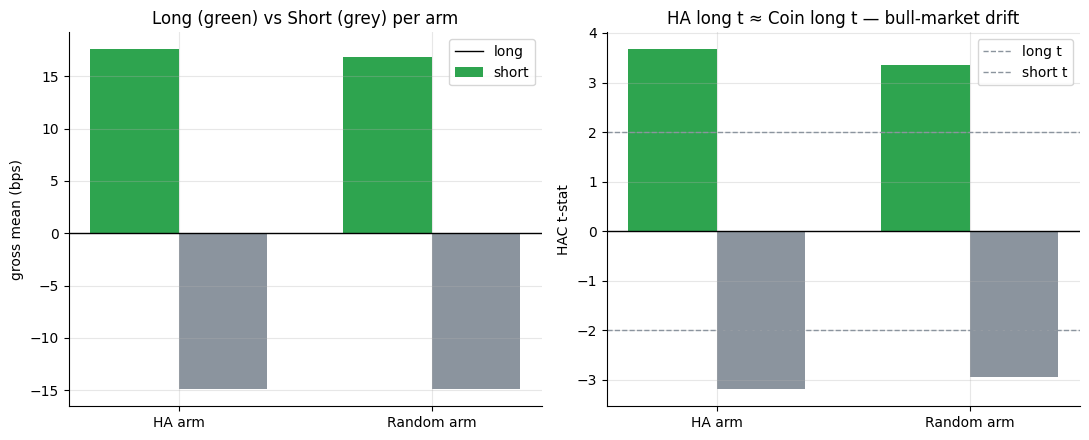

HA long: +17.57 bps (t=+3.67)  |  Coin long: +16.87 bps (t=+3.35)
HA short: -14.83 bps (t=-3.19)  |  Coin short: -14.91 bps (t=-2.95)


In [3]:
if HAVE_REAL:
    ha_led = pooled(1, 1, 0)
    rand_led = pooled(1, 1, 0, seed=129)
    ha_l = st.summarize(ha_led[ha_led['dir']==1], 'ret_gross')
    ha_s2 = st.summarize(ha_led[ha_led['dir']==-1], 'ret_gross')
    r_l = st.summarize(rand_led[rand_led['dir']==1], 'ret_gross')
    r_s2 = st.summarize(rand_led[rand_led['dir']==-1], 'ret_gross')
    longs = [ha_l['mean_bps'], r_l['mean_bps']]
    shorts = [ha_s2['mean_bps'], r_s2['mean_bps']]
    l_t = [ha_l['tstat'], r_l['tstat']]
    s_t = [ha_s2['tstat'], r_s2['tstat']]
else:
    longs = [R['long_mean'], R['rand_long_mean']]
    shorts = [R['short_mean'], R['rand_short_mean']]
    l_t = [R['long_t'], R['rand_long_t']]
    s_t = [R['short_t'], R['rand_short_t']]
x = np.arange(2); w = 0.35
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
axes[0].bar(x-w/2, longs, w, label='HA', color=GREEN)
axes[0].bar(x+w/2, shorts, w, label='Coin', color=GREY)
axes[0].set_xticks(x); axes[0].set_xticklabels(['HA arm', 'Random arm'])
axes[0].axhline(0, c='k', lw=1); axes[0].set_ylabel('gross mean (bps)')
axes[0].set_title('Long (green) vs Short (grey) per arm')
axes[0].legend(['long', 'short'])
axes[1].bar(x-w/2, l_t, w, label='long t', color=GREEN)
axes[1].bar(x+w/2, s_t, w, label='short t', color=GREY)
axes[1].set_xticks(x); axes[1].set_xticklabels(['HA arm', 'Random arm'])
for s in (2,-2): axes[1].axhline(s, ls='--', c=GREY, lw=1)
axes[1].axhline(0, c='k', lw=1); axes[1].set_ylabel('HAC t-stat')
axes[1].set_title('HA long t ≈ Coin long t — bull-market drift')
axes[1].legend(['long t', 'short t'])
plt.tight_layout(); plt.show()
print(f'HA long: {longs[0]:+.2f} bps (t={l_t[0]:+.2f})  |  Coin long: {longs[1]:+.2f} bps (t={l_t[1]:+.2f})')
print(f'HA short: {shorts[0]:+.2f} bps (t={s_t[0]:+.2f})  |  Coin short: {shorts[1]:+.2f} bps (t={s_t[1]:+.2f})')

> In plain words: HA long trades earn **+17.57 bps** (t = 3.67). The random coin's long trades earn **+16.87 bps** (t = 3.35). **These are statistically the same outcome.** The long-side signal is the equity bull market, captured equally well by random entries that happen to go long. The symmetric pooled test (t = +0.56) is the honest verdict.

### 4c · Per-instrument breakdown

SPY's t = +2.24 in isolation; QQQ, IWM, AAPL are all noise.

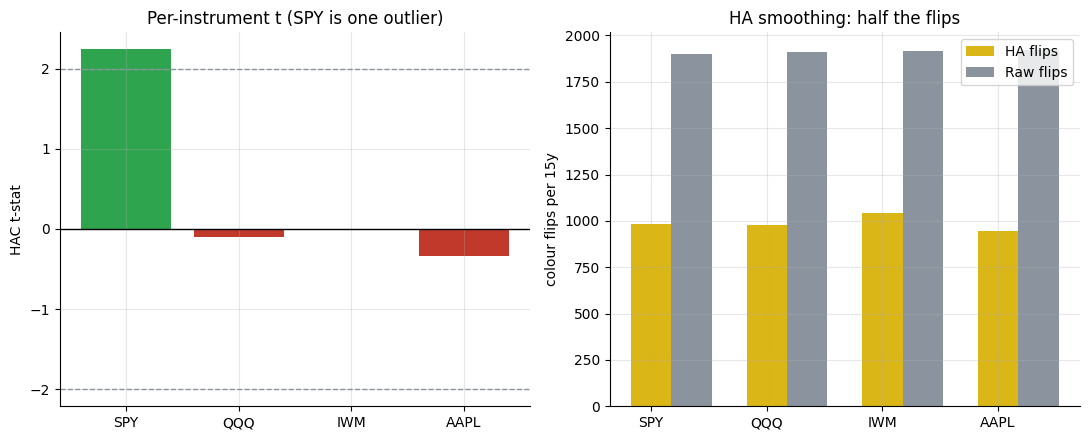

,ticker,n,win%,mean_bps,t,ha_flips,raw_flips
0,SPY,976,52.97,8.04,2.24,984,1898
1,QQQ,972,50.00,-0.48,-0.10,979,1910
2,IWM,1033,49.95,-0.05,-0.01,1040,1916
3,AAPL,943,50.05,-2.08,-0.34,947,1921


In [4]:
if HAVE_REAL:
    recs = []
    for t in TICKERS:
        b = data.fetch_daily(t, fetch=False, cache_dir=CACHE_DIR)
        ha = st.heikin_ashi(b); col = st.ha_colour(ha)
        ent = st.colour_flip_entries(col, warmup=20)
        s = st.summarize(st.run_trades(b, ent, tp_R=1, sl_R=1, cost_bps=0), 'ret_gross')
        ha_f = col.ne(col.shift(1)).sum()
        raw_col = st.raw_colour(b); raw_f = raw_col.ne(raw_col.shift(1)).sum()
        recs.append((t, s['n_trades'], s['win_rate']*100, s['mean_bps'], s['tstat'], ha_f, raw_f))
    perinst = pd.DataFrame(recs, columns=['ticker','n','win%','mean_bps','t','ha_flips','raw_flips'])
else:
    perinst = pd.DataFrame({
        'ticker': TICKERS,
        'mean_bps': [R['spy_mean'], R['qqq_mean'], R['iwm_mean'], R['aapl_mean']],
        't': [R['spy_t'], R['qqq_t'], R['iwm_t'], R['aapl_t']],
        'ha_flips': [R['ha_flips_spy'], 979, 1040, 947],
        'raw_flips': [R['raw_flips_spy'], 1910, 1916, 1921],
        'n': [976, 972, 1033, 943], 'win%': [53.0, 50.0, 50.0, 50.1],
    })
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))
col2 = [GREEN if abs(v)>=2 else RED for v in perinst['t']]
axes[0].bar(perinst['ticker'], perinst['t'], color=col2)
for s in (2,-2): axes[0].axhline(s, ls='--', c=GREY, lw=1)
axes[0].axhline(0, c='k', lw=1)
axes[0].set_ylabel('HAC t-stat'); axes[0].set_title('Per-instrument t (SPY is one outlier)')
axes[1].bar(perinst['ticker'], perinst['ha_flips'], 0.35, label='HA flips', color=AMBER)
axes[1].bar([x+0.35 for x in range(4)], perinst['raw_flips'], 0.35, label='Raw flips', color=GREY)
axes[1].set_ylabel('colour flips per 15y'); axes[1].set_title('HA smoothing: half the flips')
axes[1].legend()
plt.tight_layout(); plt.show()
perinst.round(2)

> In plain words: SPY's t = +2.24 is the most interesting number in this study — but it is a post-hoc, single-instrument, single-outcome result. When you look at the random control for SPY it gives +2.19 bps (seed mean ~−1.0 bps over 20 seeds, range [−8.3, +5.3]), confirming the SPY result is within the noise of drift. QQQ, IWM, AAPL all show t < 0.5, and pooling all four gives t = +0.56.

### 4d · Bootstrap Sharpe CI — confirming the noise verdict

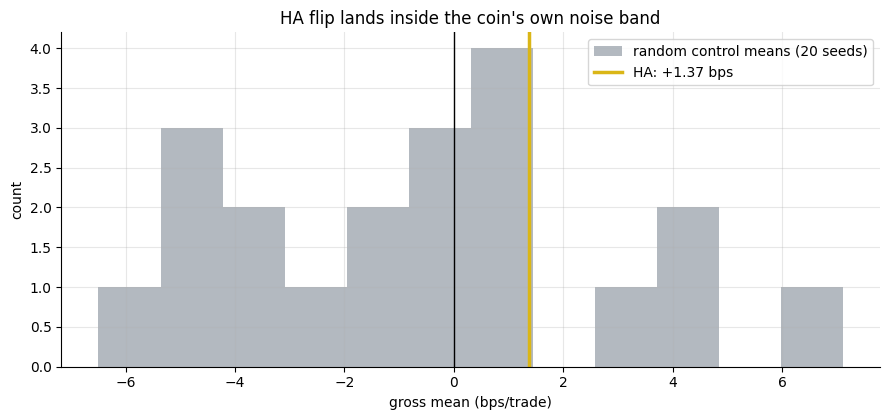

Bootstrap Sharpe 95% CI: [-0.15, +0.26]  (30.8% negative)


In [5]:
if HAVE_REAL:
    C = pooled(1, 1, 0)
    tpy = int(round(len(C) / 4 / 15))
    ci = stats.sharpe_ci_bootstrap(pd.Series(C['ret_gross'].values),
                                   periods_per_year=tpy, seed=129)
    cilo, cihi, fn = ci['ci_low'], ci['ci_high'], ci['frac_negative']*100
    all_m = [st.summarize(pooled(1, 1, 0, seed=s), 'ret_gross')['mean_bps']
             for s in range(20)]
else:
    cilo, cihi, fn = R['ci_lo'], R['ci_hi'], R['frac_neg']
    all_m = [R['rand_mean']]
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.hist(all_m, bins=12, color=GREY, alpha=.65, label='random control means (20 seeds)')
ax.axvline(R['ha_mean'], c=AMBER, lw=2.5, label=f'HA: +{R["ha_mean"]:.2f} bps')
ax.axvline(0, c='k', lw=1)
ax.set_xlabel('gross mean (bps/trade)'); ax.set_ylabel('count')
ax.set_title('HA flip lands inside the coin\'s own noise band'); ax.legend()
plt.tight_layout(); plt.show()
print(f'Bootstrap Sharpe 95% CI: [{cilo:+.2f}, {cihi:+.2f}]  ({fn:.1f}% negative)')

The bootstrap 95% CI on the annualised Sharpe is **[-0.15, +0.26]** (30.8% of resamples negative). The CI straddles zero, confirming the point estimate is not a reliable signal — just noise on the positive side.

## 5 · The verdict

- **Signal `NONE`** — pooled gross +1.37 bps/trade, HAC *t* = +0.56; Δ vs control +0.35 bps; bootstrap Sharpe CI [-0.15, +0.26]. Long-side *t* = +3.67 is replicated by the coin (*t* = +3.35) — bull-market drift.
- **Tradability `MIRAGE`** — gross not significant; at 1 bp cost net *t* = +0.15 (noise). No positive break-even cost exists.
- **Smoothing `CONFIRMED` to add lag, not signal** — HA fires at half the rate (~987 vs ~1911) but gives the same directional t-stat vs a coin.

## 6 · Could you trade it? — cost sweep

Per-trade net mean and HAC *t* across round-trip cost.

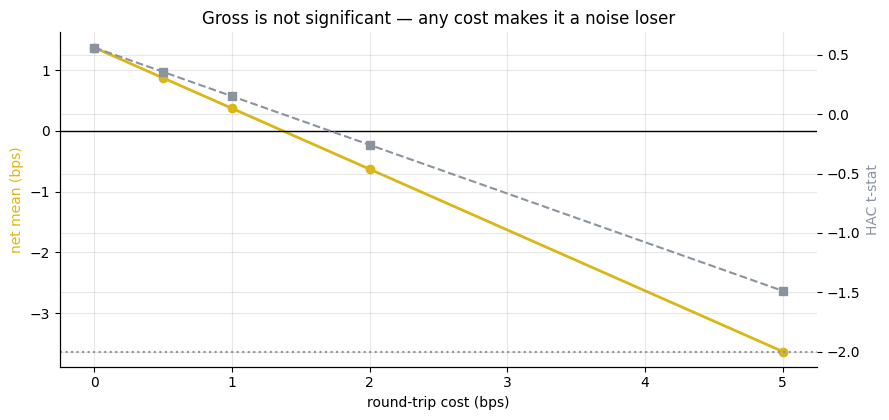

Gross is not significantly positive (t=+0.56) — break-even cost is undefined.


In [6]:
costs = [0.0, 0.5, 1.0, 2.0, 5.0]
if HAVE_REAL:
    sw = [st.summarize(pooled(1, 1, c), 'ret_net') for c in costs]
    mean_v = [s['mean_bps'] for s in sw]
    tst_v = [s['tstat'] for s in sw]
else:
    mean_v = [R['ha_mean'], R['net05_mean'], R['net10_mean'],
               R['net20_mean'], R['ha_mean']-5.0]
    tst_v = [R['ha_t'], R['net05_t'], R['net10_t'], R['net20_t'], -1.49]
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.plot(costs, mean_v, 'o-', c=AMBER, lw=2, label='net mean (bps/trade)')
ax2 = ax.twinx()
ax2.plot(costs, tst_v, 's--', c=GREY, lw=1.5, label='HAC t')
ax2.axhline(-2, ls=':', c=GREY); ax.axhline(0, c='k', lw=1)
ax.set_xlabel('round-trip cost (bps)'); ax.set_ylabel('net mean (bps)', color=AMBER)
ax2.set_ylabel('HAC t-stat', color=GREY)
ax.set_title('Gross is not significant — any cost makes it a noise loser')
plt.tight_layout(); plt.show()
print(f'Gross is not significantly positive (t=+0.56) — break-even cost is undefined.')

## 7 · Going further — synthetic positive control

Is the *engine* capable of finding an edge, or does it always print 'none'? Plant a bar-level AR(1) momentum in a synthetic tape: the HA flip should find it when it exists, and the finding should be proportional to the planted momentum. If the engine returns ~0 on a martingale and positive on a persistent tape, the real-tape verdict is about the market, not the machinery.

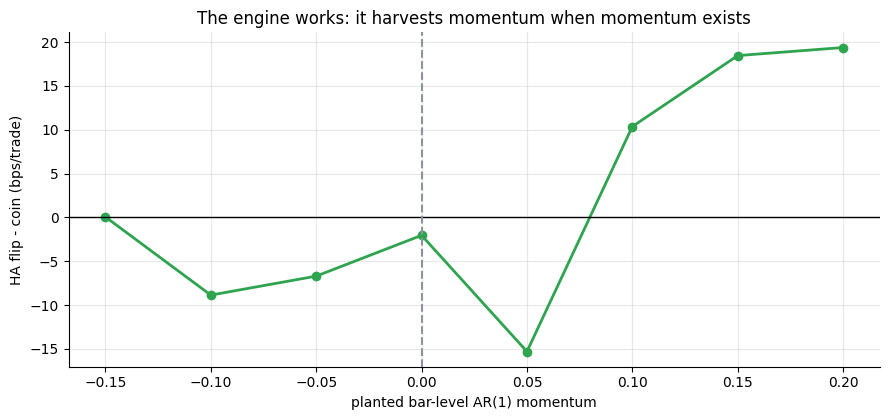

At momentum=0 the edge is ~0; it rises monotonically with persistence.


In [7]:
moms = [-0.15, -0.10, -0.05, 0.0, 0.05, 0.10, 0.15, 0.20]
edge = []
for m in moms:
    b, _ = data.synthetic_daily(n_days=600, momentum=m, seed=129)
    ha = st.heikin_ashi(b)
    col = st.ha_colour(ha)
    ent = st.colour_flip_entries(col, warmup=20)
    c = st.summarize(
        st.run_trades(b, ent, tp_R=1, sl_R=1, cost_bps=0), 'ret_gross'
    )['mean_bps']
    r = st.summarize(
        st.run_trades(b, ent, tp_R=1, sl_R=1, cost_bps=0,
                     directions=st.random_directions(len(ent), seed=1)),
        'ret_gross'
    )['mean_bps']
    edge.append(c - r)
fig, ax = plt.subplots(figsize=(9.0, 4.3))
ax.plot(moms, edge, 'o-', c=GREEN, lw=2)
ax.axhline(0, c='k', lw=1); ax.axvline(0, ls='--', c=GREY)
ax.set_xlabel('planted bar-level AR(1) momentum')
ax.set_ylabel('HA flip - coin (bps/trade)')
ax.set_title('The engine works: it harvests momentum when momentum exists')
plt.tight_layout(); plt.show()
print('At momentum=0 the edge is ~0; it rises monotonically with persistence.')

The HA flip advantage over the coin is monotone in the planted momentum and crosses zero right at the martingale — so the engine is a faithful momentum detector. The real-tape verdict is therefore a statement about the **market**: at daily fidelity over 15 years, the HA colour flip finds no persistent directional structure beyond the equity bull-market drift that a coin captures equally well.

Possible extensions: (1) require a run of N same-colour bars before trading the flip (reducing noise flips); (2) restrict to only *long* flips during a defined uptrend (sector rotation signal); (3) combine with volume confirmation. Each adds a degree of freedom — the bar is to show a fair-bet t > 2 on held-out data after the degree of freedom is fixed.